# Phase 4: Statistical Validation

Deep EDA (Phase 3) found several rating differences between groups by eye. This notebook tests which of them actually hold up.

**Ground rules (from `plan.md` §5):**
- Every rating test runs on **`df_rated`** (rating > 0). The 2,139 unrated restaurants have *no* rating, not a rating of 0.
- At n ≈ 6,500 almost any difference is statistically significant, so **effect size decides**. Every test reports a p-value, an effect size and a 95% CI.
- **Holm correction** across the family of 6 tests, at α = 0.05.
- A significant result with a negligible effect size is reported as a **null result**.
- Where a group difference could be explained by another variable, a **confound check** follows the test (descriptive, not part of the Holm family).

| # | Question | Test | Effect size |
|---|---|---|---|
| 1 | Do table-booking restaurants rate higher? | Welch's t-test | Cohen's d |
| 2 | Do chains rate differently from independent restaurants? | Welch's t-test | Cohen's d |
| 3 | Do restaurants outside NCR rate differently from NCR ones? | Welch's t-test | Cohen's d |
| 4 | Does rating differ across price ranges? | Welch's ANOVA + Tukey HSD | η² |
| 5 | Do online-delivery restaurants rate differently? | Mann-Whitney U | rank-biserial r |
| 6 | Is online delivery independent of price range? | Chi-square | Cramér's V |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.oneway import anova_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

# Chart styling: one accent colour for data, recessive grey axes and gridlines
ACCENT = '#2a78d6'
INK = '#0b0b0b'
INK_2 = '#52514e'
MUTED = '#898781'
GRID = '#e1e0d9'
AXIS = '#c3c2b7'
SURFACE = '#fcfcfb'
NEGLIGIBLE_BAND = '#f0efec'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK_2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 1, 'grid.linestyle': '-',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'semibold', 'axes.titlecolor': INK,
})

In [2]:
df = pd.read_csv('Output/df_featured.csv')
df_rated = df[df['Is Rated']].copy()

RATING = 'Aggregate rating'
ALPHA = 0.05

print(f"All rows: {len(df):,} | Rated rows (df_rated): {len(df_rated):,} | Unrated rows: {(~df['Is Rated']).sum():,}")
print(f"Rating range on df_rated: {df_rated[RATING].min()} - {df_rated[RATING].max()}")

All rows: 8,643 | Rated rows (df_rated): 6,504 | Unrated rows: 2,139
Rating range on df_rated: 1.8 - 4.9


# 1. Assumption checks

In [3]:
# Normality of Aggregate rating on df_rated: shape statistics + D'Agostino-Pearson test
ratings = df_rated[RATING]
k2, p_norm = stats.normaltest(ratings)
print(f'n = {len(ratings):,}, distinct rating values = {ratings.nunique()} (a 0.1-step scale, so the data is discrete)')
print(f'mean = {ratings.mean():.3f}, median = {ratings.median():.2f}')
print(f'skew = {ratings.skew():.3f}, excess kurtosis = {ratings.kurt():.3f}')
print(f"D'Agostino-Pearson K² = {k2:.2f}, p = {p_norm:.3g}")

n = 6,504, distinct rating values = 32 (a 0.1-step scale, so the data is discrete)
mean = 3.351, median = 3.30
skew = 0.225, excess kurtosis = -0.176
D'Agostino-Pearson K² = 63.60, p = 1.55e-14


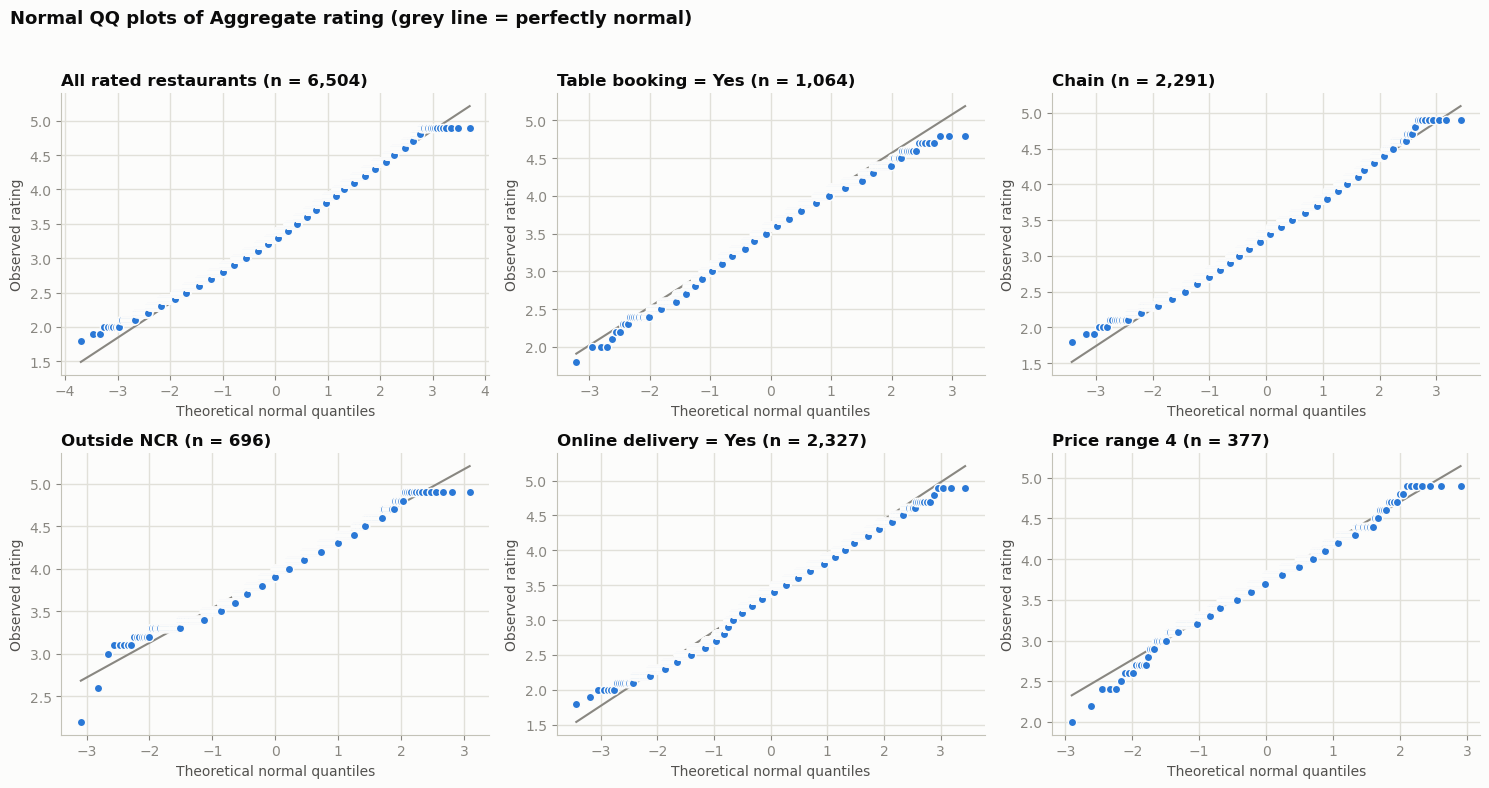

In [4]:
# QQ plots: all rated restaurants, plus the smaller group of each comparison
# (small groups are where non-normality would matter most for a t-test)
qq_panels = [
    ('All rated restaurants', df_rated[RATING]),
    ('Table booking = Yes', df_rated.loc[df_rated['Has Table booking'] == 1, RATING]),
    ('Chain', df_rated.loc[df_rated['Is Chain'], RATING]),
    ('Outside NCR', df_rated.loc[~df_rated['Is NCR'], RATING]),
    ('Online delivery = Yes', df_rated.loc[df_rated['Has Online delivery'] == 1, RATING]),
    ('Price range 4', df_rated.loc[df_rated['Price range'] == 4, RATING]),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (title, values) in zip(axes.flat, qq_panels):
    (theoretical, observed), (slope, intercept, _) = stats.probplot(values, dist='norm')
    ax.plot(theoretical, slope * theoretical + intercept, color=MUTED, linewidth=1.5, zorder=2)
    ax.scatter(theoretical, observed, s=36, color=ACCENT, edgecolor=SURFACE, linewidth=1, zorder=3)
    ax.set_title(f'{title} (n = {len(values):,})', loc='left')
    ax.set_xlabel('Theoretical normal quantiles')
    ax.set_ylabel('Observed rating')
fig.suptitle('Normal QQ plots of Aggregate rating (grey line = perfectly normal)',
             x=0.01, ha='left', fontsize=13, fontweight='semibold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Observation:
- Rating on `df_rated` is **not normal in the strict sense** (D'Agostino-Pearson p = 1.55e-14), but the departure is mild: skew 0.225, excess kurtosis -0.176, mean 3.351 vs median 3.30.
- The QQ plots show the two causes. **The scale is discrete** (32 distinct values in 0.1 steps), so points stack into short horizontal runs. **The tails are short, not long:** the scale tops out at 4.9 and bottoms out at 1.8, so the highest points flatten below the line and the lowest sit above it, instead of flaring away. There are no heavy tails dragging the means around.
- Outside NCR (n = 696) bends most at the low end: two isolated ratings (2.2 and 2.6) fall below the line, while the next values (3.0-3.3) sit above it. Price range 4, the smallest group (n = 377), tracks the line closely apart from the 4.9 ceiling.
- **Consequence:** tests on means are safe here. Every group has n ≥ 377, so by the central limit theorem the sampling distribution of each mean is close to normal even though individual ratings are not. Test 5 still uses the rank-based Mann-Whitney U as a distribution-free check.

In [5]:
# Levene's test (median-centred, which is robust to non-normal data) for equal variances in every grouping tested below
levene_rows = []
for col in ['Has Table booking', 'Is Chain', 'Is NCR', 'Has Online delivery', 'Price range']:
    groups = [g[RATING].to_numpy() for _, g in df_rated.groupby(col)]
    stat, p = stats.levene(*groups, center='median')
    sds = df_rated.groupby(col)[RATING].std()
    levene_rows.append({
        'Grouping': col,
        'Levene W': round(stat, 2),
        'p-value': f'{p:.3g}',
        'SD per group': {k: round(v, 3) for k, v in sds.items()},
        'SD ratio (max/min)': round(sds.max() / sds.min(), 2),
    })
pd.DataFrame(levene_rows)

,Grouping,Levene W,p-value,SD per group,SD ratio (max/min)
0,Has Table booking,2.79,0.0952,"{0: 0.494, 1: 0.512}",1.04
1,Is Chain,5.86,0.0155,"{False: 0.492, True: 0.523}",1.06
2,Is NCR,14.12,0.000173,"{False: 0.409, True: 0.466}",1.14
3,Has Online delivery,25.08,5.65e-07,"{0: 0.485, 1: 0.537}",1.11
4,Price range,45.03,8.57e-29,"{1: 0.403, 2: 0.501, 3: 0.519, 4: 0.485}",1.29


### Observation:
- **Unequal variances are detected in 4 of the 5 groupings:** chain (p = 0.0155), NCR (p = 0.000173), online delivery (p = 5.65e-07) and price range (p = 8.57e-29). Table booking is the only one where equal variances are not rejected (p = 0.0952).
- **The differences are small in practice.** The largest SD ratio is 1.29 (price range 1, SD 0.403, vs price range 3, SD 0.519); the two-group ratios are only 1.04-1.14. At n = 6,504 Levene flags even these: the same "significant is not the same as big" problem this whole phase is about.
- **Decision:** use the unequal-variance versions everywhere, since they cost nothing when variances happen to be equal: Welch's t-test for Tests 1-3 and Welch's ANOVA for Test 4.

# 2. Helper functions

Effect sizes, bootstrap confidence intervals, and a shared `results` store that the Holm correction reads in section 4.

In [6]:
# ---------- Effect sizes ----------
def cohens_d(a, b):
    # Standardised mean difference (a - b), scaled by the pooled standard deviation
    na, nb = len(a), len(b)
    pooled_var = ((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2)
    return (a.mean() - b.mean()) / np.sqrt(pooled_var)

def rank_biserial(a, b):
    # P(a > b) - P(a < b) for a random pair, derived from Mann-Whitney U. Ranges from -1 to 1
    u_a = stats.mannwhitneyu(a, b, alternative='two-sided').statistic
    return 2 * u_a / (len(a) * len(b)) - 1

def eta_squared(*groups):
    # Share of total rating variance explained by group membership (SS_between / SS_total)
    values = np.concatenate(groups)
    grand_mean = values.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((values - grand_mean) ** 2).sum()
    return ss_between / ss_total

def cramers_v(pairs):
    # pairs: (n, 2) array, one row per restaurant -> contingency table -> Cramér's V (0 = independent, 1 = fully associated)
    row_levels, row_codes = np.unique(pairs[:, 0], return_inverse=True)
    col_levels, col_codes = np.unique(pairs[:, 1], return_inverse=True)
    table = np.zeros((len(row_levels), len(col_levels)))
    np.add.at(table, (row_codes, col_codes), 1)
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    return np.sqrt(chi2 / (table.sum() * (min(table.shape) - 1)))

# ---------- 95% confidence interval by bootstrap ----------
def bootstrap_ci(stat_fn, samples, n_boot=2000, seed=42):
    # Percentile 95% CI for stat_fn(*samples). Each sample is resampled with replacement at its own size,
    # so group sizes stay fixed. The fixed seed makes every CI reproducible.
    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    for i in range(n_boot):
        boot[i] = stat_fn(*[s[rng.integers(0, len(s), len(s))] for s in samples])
    return np.percentile(boot, [2.5, 97.5])

# ---------- Magnitude labels (conventional cut-offs: small / medium / large) ----------
THRESHOLDS = {
    "Cohen's d":       (0.2, 0.5, 0.8),
    'eta²':            (0.01, 0.06, 0.14),
    'rank-biserial r': (0.1, 0.3, 0.5),
    "Cramér's V":      (0.1, 0.3, 0.5),   # cut-offs for min(rows, cols) - 1 = 1, which is our 4x2 table
}

def magnitude(measure, value):
    small, medium, large = THRESHOLDS[measure]
    size = abs(value)
    if size < small:
        return 'negligible'
    if size < medium:
        return 'small'
    if size < large:
        return 'medium'
    return 'large'

def fmt_p(p):
    return '< 1e-300' if p == 0 else f'{p:.3g}'

# ---------- Results store ----------
results = {}   # test name -> one result row (re-running a test cell overwrites its row instead of duplicating it)

def record(test, question, method, statistic, p, measure, effect, ci):
    results[test] = {
        'Test': test, 'Question': question, 'Method': method, 'Statistic': statistic,
        'p (raw)': p, 'Effect measure': measure, 'Effect size': effect,
        'CI low': ci[0], 'CI high': ci[1], 'Magnitude': magnitude(measure, effect),
    }
    print(f"{measure} = {effect:.3f} (95% CI {ci[0]:.3f} to {ci[1]:.3f}) -> {results[test]['Magnitude']}")

# ---------- Two-group Welch's t-test ----------
def welch_two_group(test, question, col, a_value, b_value, a_name, b_name):
    a = df_rated.loc[df_rated[col] == a_value, RATING].to_numpy()
    b = df_rated.loc[df_rated[col] == b_value, RATING].to_numpy()
    res = stats.ttest_ind(a, b, equal_var=False)
    ci = res.confidence_interval(0.95)
    print(f'{a_name}: n = {len(a):,}, mean = {a.mean():.3f}, SD = {a.std(ddof=1):.3f}')
    print(f'{b_name}: n = {len(b):,}, mean = {b.mean():.3f}, SD = {b.std(ddof=1):.3f}')
    print(f'Mean difference ({a_name} - {b_name}) = {a.mean() - b.mean():+.3f} (95% CI {ci.low:+.3f} to {ci.high:+.3f})')
    print(f"Welch's t = {res.statistic:.2f}, df = {res.df:.1f}, p = {fmt_p(res.pvalue)}")
    record(test, question, "Welch's t-test", f't = {res.statistic:.2f}', res.pvalue,
           "Cohen's d", cohens_d(a, b), bootstrap_ci(cohens_d, [a, b]))

# ---------- Confound check: does a gap survive inside each price range? ----------
# Descriptive only, not part of the Holm family. Pass `data` to run it on a subset (e.g. NCR only)
def within_price_range(col, a_value, b_value, a_name, b_name, data=None):
    data = df_rated if data is None else data
    rows = []
    for price, g in data.groupby('Price range'):
        a = g.loc[g[col] == a_value, RATING].to_numpy()
        b = g.loc[g[col] == b_value, RATING].to_numpy()
        both = len(a) > 1 and len(b) > 1
        rows.append({
            'Price range': price,
            f'n {a_name}': len(a),
            f'n {b_name}': len(b),
            f'mean {a_name}': round(a.mean(), 3) if len(a) else np.nan,
            f'mean {b_name}': round(b.mean(), 3) if len(b) else np.nan,
            'difference': round(a.mean() - b.mean(), 3) if both else np.nan,
            "Cohen's d": round(cohens_d(a, b), 3) if both else np.nan,
        })
    return pd.DataFrame(rows).set_index('Price range')

# 3. Hypothesis tests

## Test 1: Do table-booking restaurants rate higher?
**H0:** mean rating is the same with and without table booking. **Test:** Welch's t-test (does not assume equal variances). **Effect size:** Cohen's d.

In [7]:
welch_two_group('Table booking', 'Do table-booking restaurants rate higher?',
                'Has Table booking', 1, 0, 'Booking', 'No booking')

Booking: n = 1,064, mean = 3.550, SD = 0.512
No booking: n = 5,440, mean = 3.312, SD = 0.494
Mean difference (Booking - No booking) = +0.238 (95% CI +0.204 to +0.271)
Welch's t = 13.93, df = 1474.6, p = 1.55e-41
Cohen's d = 0.479 (95% CI 0.414 to 0.548) -> small


In [8]:
# Confound check 1 - price: table booking is concentrated in the expensive tiers, so compare within each price range
print('Share of rated restaurants offering table booking, by price range:')
print((df_rated.groupby('Price range')['Has Table booking'].mean() * 100).round(1).astype(str) + '%')
within_price_range('Has Table booking', 1, 0, 'Booking', 'No booking')

Share of rated restaurants offering table booking, by price range:
Price range
1     0.0%
2     8.8%
3    56.0%
4    64.5%
Name: Has Table booking, dtype: object


,n Booking,n No booking,mean Booking,mean No booking,difference,Cohen's d
Price range,,,,,,
1,1,2586,3.700,3.194,NaN,NaN
2,216,2246,3.356,3.310,0.046,0.092
3,604,474,3.590,3.792,-0.202,-0.398
4,243,134,3.624,3.936,-0.312,-0.675


In [9]:
# Confound check 2 - region: outside-NCR restaurants rate much higher (Test 3), so check how they split by booking
split = df_rated.groupby(['Price range', 'Has Table booking'])['Is NCR'].agg(
    rated_rows='size', outside_ncr_share=lambda s: 1 - s.mean())
print('Share of restaurants outside NCR, by price range and table booking:')
print(split.round(3))

# Hold region fixed as well: the same booking comparison inside NCR only
print('\nTable booking vs rating within each price range, NCR restaurants only:')
within_price_range('Has Table booking', 1, 0, 'Booking', 'No booking', data=df_rated[df_rated['Is NCR']])

Share of restaurants outside NCR, by price range and table booking:
                               rated_rows  outside_ncr_share
Price range Has Table booking                               
1           0                        2586              0.022
            1                           1              0.000
2           0                        2246              0.110
            1                         216              0.065
3           0                         474              0.527
            1                         604              0.075
4           0                         134              0.597
            1                         243              0.012

Table booking vs rating within each price range, NCR restaurants only:


,n Booking,n No booking,mean Booking,mean No booking,difference,Cohen's d
Price range,,,,,,
1,1,2530,3.700,3.179,NaN,NaN
2,202,1998,3.298,3.241,0.057,0.123
3,559,224,3.543,3.621,-0.078,-0.151
4,240,54,3.616,3.780,-0.163,-0.356


### Observation:
- **Raw comparison:** booking restaurants rate +0.238 higher (3.550 vs 3.312; 95% CI +0.204 to +0.271). Cohen's d = 0.479 (CI 0.414 to 0.548) is a "small" effect bordering on medium, and highly significant (p = 1.55e-41).
- **But it is almost entirely a price effect.** Booking is offered by 0% of price range 1, 8.8% of range 2, 56.0% of range 3 and 64.5% of range 4, so "has booking" mostly means "is expensive", and expensive restaurants rate higher (Test 4). Inside each price range the gap vanishes or reverses: +0.046 in range 2 (d = 0.092, negligible), **-0.202 in range 3 (d = -0.398) and -0.312 in range 4 (d = -0.675)**. Range 1 has a single booking restaurant, so it can't be compared. This is **Simpson's paradox**: the overall direction is the opposite of the direction inside the groups.
- **Most of the reversal comes from region.** In ranges 3 and 4, restaurants *without* booking are mostly outside NCR (52.7% and 59.7%), against 7.5% and 1.2% of those with booking, and outside-NCR restaurants rate much higher (Test 3). Holding region fixed too (NCR only), the booking gap is small and changes sign by price range: +0.057 in range 2 (d = 0.123), -0.078 in range 3 (d = -0.151), -0.163 in range 4 (d = -0.356, from only 54 non-booking restaurants).
- **Conclusion:** the Phase 3 finding "booking restaurants rate higher" does not hold as an independent effect. Table booking is a proxy for price tier and, within the premium tiers, for being in NCR. It should not be presented as a lever that raises ratings.

## Test 2: Do chains rate differently from independent restaurants?
**H0:** mean rating is the same for chain outlets and independent restaurants. **Test:** Welch's t-test. **Effect size:** Cohen's d.

In [10]:
welch_two_group('Chain vs independent', 'Do chains rate differently from independent restaurants?',
                'Is Chain', True, False, 'Chain', 'Independent')

Chain: n = 2,291, mean = 3.305, SD = 0.523
Independent: n = 4,213, mean = 3.377, SD = 0.492
Mean difference (Chain - Independent) = -0.072 (95% CI -0.098 to -0.046)
Welch's t = -5.42, df = 4466.5, p = 6.41e-08
Cohen's d = -0.143 (95% CI -0.194 to -0.092) -> negligible


### Observation:
- Chains rate slightly lower: -0.072 (3.305 vs 3.377; 95% CI -0.098 to -0.046), Cohen's d = -0.143 (CI -0.194 to -0.092).
- The difference is statistically significant (p = 6.41e-08) but **negligible**: the whole CI lies inside the ±0.2 negligible band, so even the most generous reading doesn't reach a small effect.
- **Verdict: null.** Being a chain outlet neither helps nor hurts rating in any meaningful way. This confirms the Phase 3 observation (3.30 vs 3.38) and now puts a size on it.

## Test 3: Do restaurants outside NCR rate differently from NCR ones?
Flagged in Phase 3: outside-NCR restaurants looked much better rated (3.94 vs 3.28), on a far smaller sample.

**H0:** mean rating is the same inside and outside NCR. **Test:** Welch's t-test. **Effect size:** Cohen's d.

In [11]:
welch_two_group('Outside NCR vs NCR', 'Do restaurants outside NCR rate differently from NCR ones?',
                'Is NCR', False, True, 'Outside NCR', 'NCR')

Outside NCR: n = 696, mean = 3.945, SD = 0.409
NCR: n = 5,808, mean = 3.280, SD = 0.466
Mean difference (Outside NCR - NCR) = +0.665 (95% CI +0.632 to +0.697)
Welch's t = 39.84, df = 925.3, p = 6.12e-203


Cohen's d = 1.443 (95% CI 1.368 to 1.522) -> large


In [12]:
# Is the gap explained by price, or by which restaurants made it into the dataset?
# Confound check 1 - price: the same comparison inside each price range
display(within_price_range('Is NCR', False, True, 'Outside NCR', 'NCR'))

# Sample profile: popularity, cost, chain share, city spread, and how many restaurants were left unrated
profile = df_rated.groupby('Is NCR').agg(
    rated_rows=(RATING, 'size'),
    median_votes=('Votes', 'median'),
    mean_cost=('Average Cost for two', 'mean'),
    chain_share=('Is Chain', 'mean'),
    cities=('City', 'nunique'),
)
profile['unrated_share_all_rows'] = (~df['Is Rated']).groupby(df['Is NCR']).mean()
profile.index = profile.index.map({True: 'NCR', False: 'Outside NCR'})
profile.round(3)

,n Outside NCR,n NCR,mean Outside NCR,mean NCR,difference,Cohen's d
Price range,,,,,,
1,56,2531,3.879,3.179,0.700,1.794
2,262,2200,3.888,3.246,0.642,1.395
3,295,783,3.979,3.566,0.413,0.852
4,83,294,4.048,3.646,0.402,0.880


,rated_rows,median_votes,mean_cost,chain_share,cities,unrated_share_all_rows
Is NCR,,,,,,
Outside NCR,696,192.0,894.670,0.214,38,0.000
NCR,5808,40.0,695.597,0.369,5,0.269


In [13]:
# Confound check 2 - popularity: outside-NCR restaurants have far more votes, and votes track rating.
# Votes are used here only to describe the samples, not as a predictor (see the leakage note in plan.md)
region = df_rated['Is NCR'].map({True: 'NCR', False: 'Outside NCR'})
vote_bands = pd.cut(df_rated['Votes'], [0, 10, 50, 200, 1000, np.inf],
                    labels=['≤ 10', '11-50', '51-200', '201-1,000', '> 1,000'])
print('Share of each region in each vote band:')
print(pd.crosstab(region, vote_bands, normalize='index').round(3))

band_rows = []
for band, g in df_rated.groupby(vote_bands, observed=True):
    outside = g.loc[~g['Is NCR'], RATING].to_numpy()
    ncr = g.loc[g['Is NCR'], RATING].to_numpy()
    band_rows.append({'Votes': band, 'n Outside NCR': len(outside), 'n NCR': len(ncr),
                      'mean Outside NCR': outside.mean(), 'mean NCR': ncr.mean(),
                      'difference': outside.mean() - ncr.mean(), "Cohen's d": cohens_d(outside, ncr)})
band_table = pd.DataFrame(band_rows).set_index('Votes')

# Re-weight the per-band gaps to the outside-NCR vote mix: the gap left once both samples are equally popular
weights = band_table['n Outside NCR'] / band_table['n Outside NCR'].sum()
raw_gap = df_rated.loc[~df_rated['Is NCR'], RATING].mean() - df_rated.loc[df_rated['Is NCR'], RATING].mean()
adjusted_gap = (band_table['difference'] * weights).sum()
print(f'\nRaw gap: {raw_gap:+.3f} | gap after matching the vote mix: {adjusted_gap:+.3f} '
      f'-> {1 - adjusted_gap / raw_gap:.0%} of the raw gap is explained by vote mix')
band_table.round(3)

Share of each region in each vote band:
Votes         ≤ 10  11-50  51-200  201-1,000  > 1,000
Is NCR                                               
NCR          0.181  0.375   0.287      0.131    0.026
Outside NCR  0.003  0.089   0.427      0.359    0.122

Raw gap: +0.665 | gap after matching the vote mix: +0.388 -> 42% of the raw gap is explained by vote mix


,n Outside NCR,n NCR,mean Outside NCR,mean NCR,difference,Cohen's d
Votes,,,,,,
≤ 10,2,1049,3.200,2.963,0.237,1.529
11-50,62,2179,3.571,3.153,0.418,1.144
51-200,297,1669,3.789,3.379,0.410,0.842
"201-1,000",250,761,4.104,3.724,0.380,1.028
"> 1,000",85,150,4.312,3.997,0.315,0.843


### Observation:
- **Raw comparison:** outside-NCR restaurants rate +0.665 higher (3.945 vs 3.280; 95% CI +0.632 to +0.697), Cohen's d = 1.443 (CI 1.368 to 1.522), p = 6.12e-203. This is the largest effect in Phase 4.
- **Price does not explain it.** The gap holds in every price range: +0.700 in range 1 (d = 1.794), +0.642 in range 2 (d = 1.395), +0.413 in range 3 (d = 0.852) and +0.402 in range 4 (d = 0.880). It narrows in the premium tiers but stays large.
- **The two samples do not look like they were collected the same way.** Outside NCR *every* restaurant is rated (0.0% unrated vs 26.9% in NCR), the median restaurant has 192 votes against 40 in NCR, and the 696 rated rows are spread over 38 cities (about 18 per city) against 5,808 rows in 5 NCR cities. That profile fits a selection of established, popular restaurants per city, while NCR looks like a much fuller listing that includes new and small places.
- **Popularity explains part of the gap, not all of it.** 90.8% of outside-NCR restaurants have more than 50 votes, against 44.4% in NCR. Within vote bands the gap shrinks to +0.418 (11-50 votes), +0.410 (51-200), +0.380 (201-1,000) and +0.315 (> 1,000); the ≤ 10 band holds only 2 outside-NCR restaurants. Re-weighted to the outside-NCR vote mix, the gap is **+0.388, so about 42% of the raw gap is vote mix**.
- **Conclusion:** the gap is real *in this dataset*, but it can't be read as "restaurants outside Delhi NCR are better". The outside-NCR rows are very likely a curated slice, and the remaining ~0.4 gap between equally popular restaurants could still come from how those cities were sampled. Report it with that caveat, and treat `Is NCR` as a control variable in Phase 5 rather than as a finding.

## Test 4: Does rating differ across price ranges?
**H0:** mean rating is the same in all 4 price ranges. **Test:** Welch's ANOVA (Levene showed unequal variances; the classic ANOVA is printed alongside for comparison), then Tukey HSD for the pairs. **Effect size:** η².

In [14]:
price_groups = [g[RATING].to_numpy() for _, g in df_rated.groupby('Price range')]
print(df_rated.groupby('Price range')[RATING].agg(['count', 'mean', 'median', 'std']).round(3))

classic = stats.f_oneway(*price_groups)
welch = anova_oneway(df_rated[RATING], df_rated['Price range'], use_var='unequal')
print(f'\nClassic one-way ANOVA: F = {classic.statistic:.2f}, p = {fmt_p(classic.pvalue)}')
print(f"Welch's ANOVA:         F = {welch.statistic:.2f}, df = (3, {welch.df_denom:.1f}), p = {fmt_p(welch.pvalue)}")

record('Price range', 'Does rating differ across price ranges?', "Welch's ANOVA", f'F = {welch.statistic:.2f}',
       welch.pvalue, 'eta²', eta_squared(*price_groups), bootstrap_ci(eta_squared, price_groups))

             count   mean  median    std
Price range                             
1             2587  3.194     3.1  0.403
2             2462  3.314     3.3  0.501
3             1078  3.679     3.7  0.519
4              377  3.735     3.8  0.485

Classic one-way ANOVA: F = 364.36, p = 9.93e-219
Welch's ANOVA:         F = 347.35, df = (3, 1476.4), p = 1.22e-170


eta² = 0.144 (95% CI 0.129 to 0.161) -> large


In [15]:
# Post-hoc: which price ranges differ? (Tukey HSD already controls the error rate across its 6 pairs)
tukey = pairwise_tukeyhsd(df_rated[RATING], df_rated['Price range'], alpha=ALPHA)
tukey_table = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])

# Add Cohen's d per pair, so each step up in price has a size and not just a p-value
def price_ratings(price):
    return df_rated.loc[df_rated['Price range'] == price, RATING].to_numpy()

tukey_table["Cohen's d"] = [round(cohens_d(price_ratings(g2), price_ratings(g1)), 3)
                            for g1, g2 in zip(tukey_table['group1'], tukey_table['group2'])]
tukey_table

,group1,group2,meandiff,p-adj,lower,upper,reject,Cohen's d
0,1,2,0.1202,0.0000,0.0864,0.1539,True,0.265
1,1,3,0.4844,0.0000,0.4409,0.5279,True,1.101
2,1,4,0.5406,0.0000,0.4745,0.6067,True,1.305
3,2,3,0.3642,0.0000,0.3204,0.4080,True,0.719
4,2,4,0.4204,0.0000,0.3541,0.4867,True,0.842
5,3,4,0.0562,0.1837,-0.0156,0.1279,False,0.110


### Observation:
- **Rating rises with price tier:** 3.194 (range 1) → 3.314 (range 2) → 3.679 (range 3) → 3.735 (range 4). Welch's ANOVA gives F = 347.35, p = 1.22e-170, and the classic ANOVA agrees (F = 364.36).
- **η² = 0.144 (95% CI 0.129 to 0.161):** price range alone accounts for about 14% of the variance in rating. The point estimate is just over the 0.14 "large" cut-off but the CI straddles it, so **medium-to-large** is the honest label.
- **Tukey HSD shows where the jump is.** 5 of the 6 pairs differ. The big step is from budget to premium: range 2 → 3 is +0.364 (d = 0.719). Range 1 → 2 is only +0.120 (d = 0.265, small), and **ranges 3 and 4 are not significantly different** (+0.056, p-adj = 0.184, d = 0.110). Rating splits into a budget tier (~3.2-3.3) and a premium tier (~3.7) rather than climbing steadily.
- Tukey HSD assumes equal variances, and the SD ratio here is 1.29. With these group sizes the 5 significant pairs are far from the threshold, and the range 3 vs 4 difference is negligible by d either way, so the conclusions don't depend on that assumption.
- **For later phases:** price tier is the confound behind the table-booking result (Test 1) and is associated with delivery (Test 6). Any rating model needs it.

## Test 5: Do online-delivery restaurants rate differently?
**H0:** ratings of delivery and non-delivery restaurants come from the same distribution. **Test:** Mann-Whitney U (rank-based, no normality assumption). **Effect size:** rank-biserial r.

In [16]:
delivery_yes = df_rated.loc[df_rated['Has Online delivery'] == 1, RATING].to_numpy()
delivery_no = df_rated.loc[df_rated['Has Online delivery'] == 0, RATING].to_numpy()
mwu = stats.mannwhitneyu(delivery_yes, delivery_no, alternative='two-sided')

print(f'Delivery:    n = {len(delivery_yes):,}, median = {np.median(delivery_yes):.2f}, mean = {delivery_yes.mean():.3f}')
print(f'No delivery: n = {len(delivery_no):,}, median = {np.median(delivery_no):.2f}, mean = {delivery_no.mean():.3f}')
print(f'Mann-Whitney U = {mwu.statistic:,.0f}, p = {fmt_p(mwu.pvalue)}')

record('Online delivery', 'Do online-delivery restaurants rate differently?', 'Mann-Whitney U',
       f'U = {mwu.statistic:,.0f}', mwu.pvalue, 'rank-biserial r',
       rank_biserial(delivery_yes, delivery_no), bootstrap_ci(rank_biserial, [delivery_yes, delivery_no]))

Delivery:    n = 2,327, median = 3.40, mean = 3.372
No delivery: n = 4,177, median = 3.30, mean = 3.339
Mann-Whitney U = 5,228,142, p = 3.74e-07


rank-biserial r = 0.076 (95% CI 0.045 to 0.107) -> negligible


In [17]:
# The methodological headline: how much of the delivery-rating link came from treating "not rated" as a 0 rating?
corr_all = df[RATING].corr(df['Has Online delivery'])
corr_rated = df_rated[RATING].corr(df_rated['Has Online delivery'])
print(f'Correlation, delivery vs rating, all {len(df):,} rows (unrated counted as 0): {corr_all:.3f}')
print(f'Correlation, delivery vs rating, {len(df_rated):,} rated rows only:            {corr_rated:.3f}')
print(f'-> {1 - corr_rated / corr_all:.0%} of the apparent link disappears once unrated rows are removed')
print(f"\nDelivery offered by {df.loc[~df['Is Rated'], 'Has Online delivery'].mean():.1%} of unrated "
      f"vs {df_rated['Has Online delivery'].mean():.1%} of rated restaurants")

Correlation, delivery vs rating, all 8,643 rows (unrated counted as 0): 0.296
Correlation, delivery vs rating, 6,504 rated rows only:            0.031
-> 89% of the apparent link disappears once unrated rows are removed

Delivery offered by 4.5% of unrated vs 35.8% of rated restaurants


### Observation:
- Delivery restaurants rate marginally higher: median 3.40 vs 3.30, mean 3.372 vs 3.339. Mann-Whitney U is significant (p = 3.74e-07), but **rank-biserial r = 0.076 (95% CI 0.045 to 0.107) is negligible**: in a random pairing, a delivery restaurant out-rates a non-delivery one only 7.6 percentage points more often than the reverse.
- The CI's upper end just crosses the 0.1 "small" cut-off, so a very small effect can't be fully ruled out, but the best estimate is negligible. **Verdict: null.**
- **The methodological headline:** the delivery-rating correlation is 0.296 across all 8,643 rows but **0.031** once unrated rows are removed, so **89% of the apparent link was an artifact** of counting "not rated" as 0. The mechanism is visible directly: only 4.5% of unrated restaurants offer delivery, against 35.8% of rated ones, so the unrated zeros pile up in the no-delivery group.
- The audit in `plan.md` §0.1 quoted 0.302 → 0.057. Those figures were computed on the old name-deduplicated base (6,592 rows). On the corrected 8,643-row base the collapse is even sharper: 0.296 → 0.031.

## Test 6: Is online delivery independent of price range?
**H0:** the share of restaurants offering delivery is the same in every price range. **Test:** chi-square test of independence. **Effect size:** Cramér's V.

In [18]:
counts = pd.crosstab(df_rated['Price range'], df_rated['Has Online delivery'])
counts.columns = ['No delivery', 'Delivery']
print('Counts (df_rated):')
print(counts)
print('\nShare offering delivery, by price range:')
print((counts['Delivery'] / counts.sum(axis=1) * 100).round(1).astype(str) + '%')

chi2, p_chi, dof, expected = stats.chi2_contingency(counts)
print(f'\nChi-square = {chi2:.2f}, df = {dof}, p = {fmt_p(p_chi)}; smallest expected cell count = {expected.min():.1f} (needs >= 5)')

pairs_rated = df_rated[['Price range', 'Has Online delivery']].to_numpy()
record('Delivery x price range', 'Is online delivery independent of price range?', 'Chi-square',
       f'chi² = {chi2:.2f}', p_chi, "Cramér's V", cramers_v(pairs_rated), bootstrap_ci(cramers_v, [pairs_rated]))

pairs_all = df[['Price range', 'Has Online delivery']].to_numpy()
print(f"(For comparison, all {len(df):,} rows: Cramér's V = {cramers_v(pairs_all):.3f})")

Counts (df_rated):
             No delivery  Delivery
Price range                       
1                   1939       648
2                   1222      1240
3                    682       396
4                    334        43

Share offering delivery, by price range:
Price range
1    25.0%
2    50.4%
3    36.7%
4    11.4%
dtype: object

Chi-square = 455.52, df = 3, p = 2.08e-98; smallest expected cell count = 134.9 (needs >= 5)


Cramér's V = 0.265 (95% CI 0.243 to 0.287) -> small
(For comparison, all 8,643 rows: Cramér's V = 0.300)


### Observation:
- **Delivery depends on price range, and not in a straight line.** The share offering delivery is 25.0% in range 1, peaks at **50.4% in range 2**, then falls to 36.7% in range 3 and 11.4% in range 4. Mid-budget restaurants deliver most; fine dining rarely does.
- Chi-square = 455.52 (df = 3, p = 2.08e-98). The smallest expected cell count is 134.9, far above the minimum of 5, so the test is valid. **Cramér's V = 0.265 (95% CI 0.243 to 0.287) is a small association**, below the 0.3 "medium" cut-off. On all 8,643 rows V is 0.300, a little stronger, because unrated restaurants are both cheap and rarely deliver.
- **Why it matters for Phase 5:** delivery and price range carry overlapping information, and the relationship is an inverted U, which a linear correlation would understate. Both can go in one model, but delivery's coefficient should be read alongside price range, never alone.

# 4. Holm correction and verdicts

Holm's step-down correction is applied across the 6 tests. Verdict rule:
- not significant after Holm → **Null: not significant**
- significant, but the effect size is below the "small" cut-off → **Null: significant but negligible**
- otherwise → **Real effect**, labelled with its magnitude

A verdict describes the raw comparison only. The **`Caveat`** column records what the confound checks in section 3 found, and is saved with the results so the caveats travel into Phase 6 reporting.

In [19]:
summary = pd.DataFrame(list(results.values()))
reject, p_holm, _, _ = multipletests(summary['p (raw)'], alpha=ALPHA, method='holm')
summary['p (Holm)'] = p_holm
summary['Significant after Holm'] = reject

def verdict(row):
    if not row['Significant after Holm']:
        return 'Null: not significant'
    if row['Magnitude'] == 'negligible':
        return 'Null: significant but negligible'
    return f"Real effect ({row['Magnitude']})"

summary['Verdict'] = summary.apply(verdict, axis=1)

# Caveats written from the confound checks and CIs in section 3
caveats = {
    'Table booking': 'Confounded by price range and region',
    'Outside NCR vs NCR': 'Sample caveat: outside-NCR rows skew popular',
    'Price range': 'CI spans the large cut-off (0.14)',
}
summary['Caveat'] = summary['Test'].map(caveats).fillna('')
summary.to_csv('Output/phase4_test_results.csv', index=False)

view = summary[['Test', 'Method', 'Statistic', 'p (raw)', 'p (Holm)', 'Effect measure', 'Effect size', 'Verdict', 'Caveat']].copy()
view['p (raw)'] = view['p (raw)'].map(fmt_p)
view['p (Holm)'] = view['p (Holm)'].map(fmt_p)
view['Effect size'] = summary['Effect size'].round(3)
view.insert(7, '95% CI', summary.apply(lambda r: f"{r['CI low']:.3f} to {r['CI high']:.3f}", axis=1))
view

,Test,Method,Statistic,p (raw),p (Holm),Effect measure,Effect size,95% CI,Verdict,Caveat
0,Table booking,Welch's t-test,t = 13.93,1.55e-41,4.64e-41,Cohen's d,0.479,0.414 to 0.548,Real effect (small),Confounded by price range and region
1,Chain vs independent,Welch's t-test,t = -5.42,6.41e-08,1.28e-07,Cohen's d,-0.143,-0.194 to -0.092,Null: significant but negligible,
2,Outside NCR vs NCR,Welch's t-test,t = 39.84,6.12e-203,3.67e-202,Cohen's d,1.443,1.368 to 1.522,Real effect (large),Sample caveat: outside-NCR rows skew popular
3,Price range,Welch's ANOVA,F = 347.35,1.22e-170,6.09e-170,eta²,0.144,0.129 to 0.161,Real effect (large),CI spans the large cut-off (0.14)
4,Online delivery,Mann-Whitney U,"U = 5,228,142",3.74e-07,3.74e-07,rank-biserial r,0.076,0.045 to 0.107,Null: significant but negligible,
5,Delivery x price range,Chi-square,chi² = 455.52,2.08e-98,8.31e-98,Cramér's V,0.265,0.243 to 0.287,Real effect (small),


### Observation:
- **All 6 tests stay significant after Holm correction.** The largest adjusted p-value is 3.74e-07 (online delivery). At n = 6,504 that's expected, and it is exactly why significance alone decides nothing here.
- **Effect sizes split the family into three groups:**
  - **Real, large:** outside NCR vs NCR (d = 1.443) and price range (η² = 0.144).
  - **Real, small:** table booking (d = 0.479) and delivery × price range (V = 0.265).
  - **Null, significant but negligible:** chain vs independent (d = -0.143) and online delivery (r = 0.076).
- **Two of the "real" verdicts are only correct with their caveat attached,** which is why the `Caveat` column is saved with the results: table booking's effect disappears once price range and region are held fixed (Test 1), and the NCR gap rests on a sample that wasn't collected like NCR's (Test 3).
- The full table is saved to `Output/phase4_test_results.csv` for Phase 6 reporting.

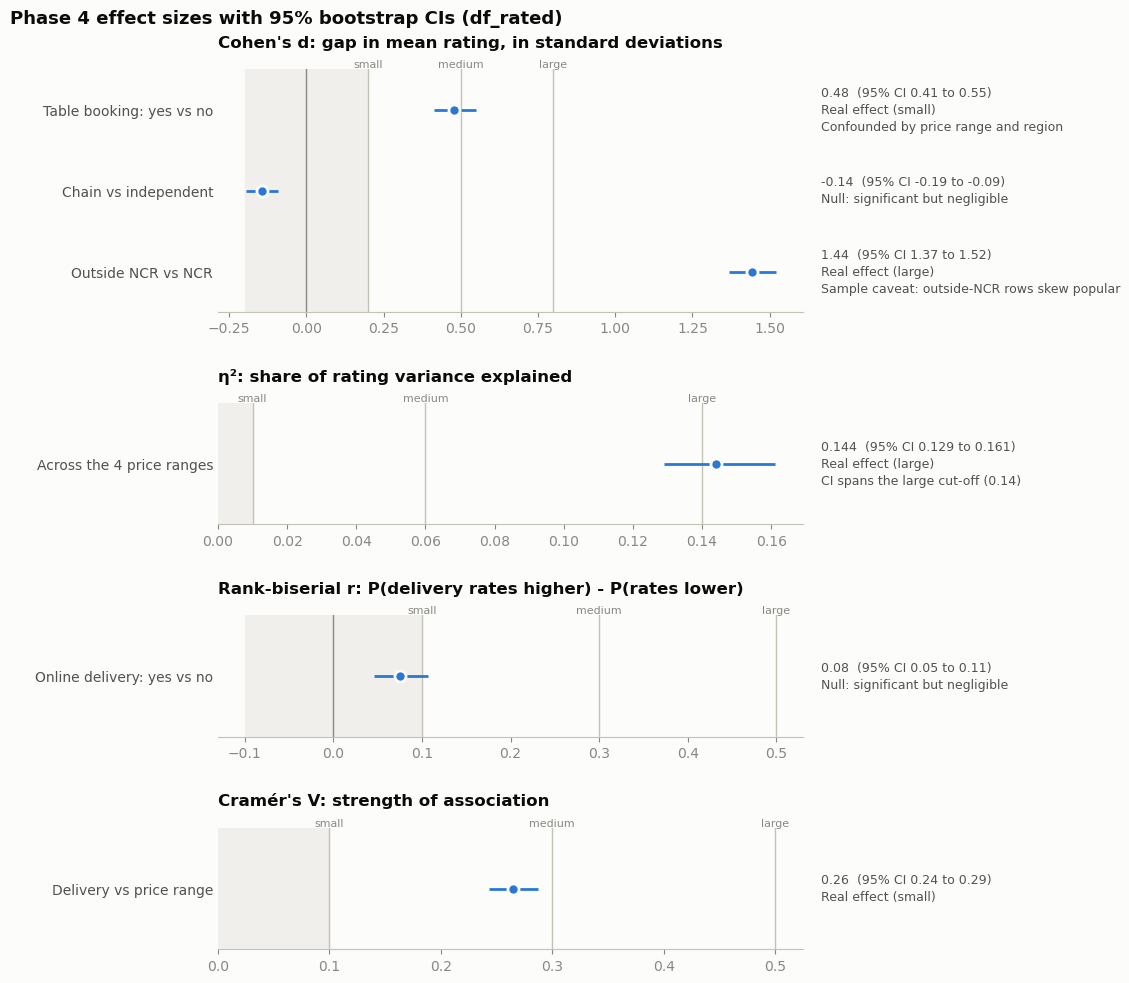

In [20]:
# Effect sizes with 95% bootstrap CIs, one panel per effect measure (each measure has its own scale).
# Shaded band = negligible zone; vertical lines mark the small / medium / large cut-offs.
row_labels = {
    'Table booking': 'Table booking: yes vs no',
    'Chain vs independent': 'Chain vs independent',
    'Outside NCR vs NCR': 'Outside NCR vs NCR',
    'Price range': 'Across the 4 price ranges',
    'Online delivery': 'Online delivery: yes vs no',
    'Delivery x price range': 'Delivery vs price range',
}
panel_titles = {
    "Cohen's d": "Cohen's d: gap in mean rating, in standard deviations",
    'eta²': 'η²: share of rating variance explained',
    'rank-biserial r': 'Rank-biserial r: P(delivery rates higher) - P(rates lower)',
    "Cramér's V": "Cramér's V: strength of association",
}
measures = list(dict.fromkeys(summary['Effect measure']))
panels = [summary[summary['Effect measure'] == m].reset_index(drop=True) for m in measures]

fig, axes = plt.subplots(len(measures), 1, figsize=(13, 10),
                         gridspec_kw={'height_ratios': [len(p) + 1 for p in panels]})
for ax, measure, rows in zip(axes, measures, panels):
    small, medium, large = THRESHOLDS[measure]
    signed = measure in ("Cohen's d", 'rank-biserial r')
    x_min = min(-small, rows['CI low'].min()) if signed else 0
    x_max = max(large, rows['CI high'].max())
    pad = 0.05 * (x_max - x_min)
    ax.set_xlim(x_min - (pad if signed else 0), x_max + pad)

    ax.grid(False)
    ax.axvspan(-small if signed else 0, small, color=NEGLIGIBLE_BAND, zorder=0)
    if signed:
        ax.axvline(0, color=MUTED, linewidth=1, zorder=1)
    for cut, name in zip((small, medium, large), ('small', 'medium', 'large')):
        ax.axvline(cut, color=AXIS, linewidth=1, zorder=1)
        ax.text(cut, 1.0, name, transform=ax.get_xaxis_transform(), ha='center', va='bottom', fontsize=8, color=MUTED)

    y = np.arange(len(rows))
    ax.hlines(y, rows['CI low'], rows['CI high'], color=ACCENT, linewidth=2, zorder=3)
    ax.scatter(rows['Effect size'], y, s=64, color=ACCENT, edgecolor=SURFACE, linewidth=2, zorder=4)

    # Right-hand column, aligned across panels: value + CI, verdict, and caveat (if any)
    decimals = 3 if measure == 'eta²' else 2
    for yi, (_, r) in zip(y, rows.iterrows()):
        lines = [f"{r['Effect size']:.{decimals}f}  (95% CI {r['CI low']:.{decimals}f} to {r['CI high']:.{decimals}f})",
                 r['Verdict']]
        if r['Caveat']:
            lines.append(r['Caveat'])
        ax.annotate('\n'.join(lines), xy=(1.03, yi), xycoords=('axes fraction', 'data'),
                    va='center', ha='left', fontsize=9, color=INK_2, linespacing=1.4, annotation_clip=False)

    ax.set_yticks(y, [row_labels[t] for t in rows['Test']])
    ax.set_ylim(len(rows) - 0.5, -0.5)
    ax.tick_params(axis='y', length=0, labelcolor=INK_2)
    ax.spines['left'].set_visible(False)
    ax.set_title(panel_titles[measure], loc='left', pad=16)

fig.suptitle('Phase 4 effect sizes with 95% bootstrap CIs (df_rated)', x=0.01, ha='left', fontsize=13, fontweight='semibold')
fig.subplots_adjust(left=0.17, right=0.62, top=0.92, bottom=0.04, hspace=0.6)
plt.show()

### Observation:
Each effect is drawn on its own scale with the negligible zone shaded. Chain vs independent sits entirely inside that zone (CI -0.19 to -0.09), and online delivery sits inside it with only the top of its CI (0.107) poking past the 0.1 line. Outside NCR vs NCR is far beyond the "large" line, and price range sits right on it with a CI that straddles it. The table-booking dot looks like a clean small effect, which is exactly why its caveat is printed beside it: the confound checks in Test 1 show the gap does not survive once price and region are held fixed.

# 5. Summary

| Question | Result | What it means |
|---|---|---|
| Does table booking raise rating? | d = 0.48 overall, but reverses inside price ranges 3-4 | **Not an independent effect.** Booking is a proxy for price tier and region (Simpson's paradox). |
| Chain vs independent? | d = -0.14, negligible | **Null.** Chain status doesn't matter for rating. |
| Outside NCR vs NCR? | d = 1.44; holds in every price range; +0.39 left after matching vote mix | **Real in this data, with a sampling caveat.** Outside-NCR rows look like a popular, fully rated slice. |
| Price range? | η² = 0.144; budget tier (1-2) vs premium tier (3-4); ranges 3 and 4 don't differ | **The strongest clean driver tested:** about 14% of rating variance. |
| Does online delivery raise rating? | r = 0.076, negligible | **Null.** The earlier link was 89% an artifact of unrated rows. |
| Delivery vs price range? | V = 0.265; delivery peaks in range 2 (50.4%) | **Associated, as an inverted U.** Read delivery together with price in any model. |

**Methodological findings to carry forward:**
1. Treating "not rated" as 0 manufactured most of the delivery-rating link (correlation 0.296 → 0.031).
2. At this sample size every test is significant. Effect sizes and confound checks are what separated the 6 results.
3. The booking result is a Simpson's paradox. Check any binary feature within price range (and region) before calling it a driver.

**Implications for Phase 3.5 and Phase 5:**
- `Price range` (or cost, not both) and `Is NCR` belong in every rating model as controls.
- Don't expect table booking or online delivery to carry much independent signal in the actionable model.
- The outside-NCR sample differs from the NCR sample in how it was collected, so check model performance on the two separately, or model NCR on its own.